In [27]:
import os
import cv2
import numpy as np
import time
import random
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# CONFIGURATION
# ==========================================
# Path to the 'Final_Training/Images' folder containing subfolders 00000 to 00042
DATASET_PATH =r"C:\Users\lenar\Downloads\GTSRB_Final_Training_Images\GTSRB\Final_Training\Images" #"GTSRB/Final_Training/Images" 
IMG_SIZE = (64, 64)  # Resize images for consistency (especially for color hist)
VOCAB_SIZE = 100     # Number of "Visual Words" for SIFT BoW
SEED = 42            # Random seed for reproducibility
SAMPLE_FRACTION = 0.2 # Use 0.2 (20%) for debugging, set to 1.0 for full run


# GTSRB Class ID to Name Mapping
GTSRB_CLASSES = {
    0: 'Speed limit (20km/h)', 1: 'Speed limit (30km/h)', 2: 'Speed limit (50km/h)', 
    3: 'Speed limit (60km/h)', 4: 'Speed limit (70km/h)', 5: 'Speed limit (80km/h)', 
    6: 'End of speed limit (80km/h)', 7: 'Speed limit (100km/h)', 8: 'Speed limit (120km/h)', 
    9: 'No passing', 10: 'No passing veh over 3.5 tons', 11: 'Right-of-way at intersection', 
    12: 'Priority road', 13: 'Yield', 14: 'Stop', 15: 'No vehicles', 
    16: 'Veh > 3.5 tons prohibited', 17: 'No entry', 18: 'General caution', 
    19: 'Dangerous curve left', 20: 'Dangerous curve right', 21: 'Double curve', 
    22: 'Bumpy road', 23: 'Slippery road', 24: 'Road narrows on the right', 
    25: 'Road work', 26: 'Traffic signals', 27: 'Pedestrians', 28: 'Children crossing', 
    29: 'Bicycles crossing', 30: 'Beware of ice/snow', 31: 'Wild animals crossing', 
    32: 'End speed + passing limits', 33: 'Turn right ahead', 34: 'Turn left ahead', 
    35: 'Ahead only', 36: 'Go straight or right', 37: 'Go straight or left', 
    38: 'Keep right', 39: 'Keep left', 40: 'Roundabout mandatory', 
    41: 'End of no passing', 42: 'End no passing veh > 3.5 tons'
}






In [4]:
# ==========================================
# 1. DATA LOADING & PREPARATION
# ==========================================
def load_gtsrb_data(base_path, sample_fraction=1.0):
    """
    Loads images and labels from the GTSRB folder structure.
    sample_fraction: Load only a subset (e.g., 0.1) for faster debugging.
    """
    print(f"[INFO] Loading data from {base_path}...")
    images = []
    labels = []
    
    # GTSRB classes are folders 00000 to 00042
    classes = sorted([d for d in os.listdir(base_path) if os.path.isdir(os.path.join(base_path, d))])
    
    for class_id, class_name in enumerate(classes):
        class_dir = os.path.join(base_path, class_name)
        img_files = os.listdir(class_dir)
        
        # Optional: verify files are images (ppm or png)
        img_files = [f for f in img_files if f.endswith('.ppm') or f.endswith('.png')]
        
        for img_file in img_files:
            # Random sampling for large datasets if needed
            if random.random() > sample_fraction:
                continue
                
            img_path = os.path.join(class_dir, img_file)
            img = cv2.imread(img_path)
            
            if img is not None:
                # Resize immediately to save memory and ensure consistency
                img = cv2.resize(img, IMG_SIZE)
                images.append(img)
                labels.append(class_id)
    
    print(f"[INFO] Loaded {len(images)} images across {len(classes)} classes.")
    return np.array(images), np.array(labels)

In [6]:
# ==========================================
# 2. FEATURE EXTRACTION STRATEGIES
# ==========================================

def extract_color_histograms(images, bins=(8, 8, 8)):
    """
    Method A: 3-Channel Color Histogram (Simple Representation)
    """
    print("[INFO] Extracting Color Histograms...")
    features = []
    for img in images:
        # Convert to HSV (more robust for traffic signs than BGR)
        hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
        
        # Compute histogram
        hist = cv2.calcHist([hsv], [0, 1, 2], None, bins, [0, 180, 0, 256, 0, 256])
        
        # Normalize to account for different image scales (if not resized)
        cv2.normalize(hist, hist)
        features.append(hist.flatten())
        
    return np.array(features)

In [7]:
class VisualBagOfWords:
    """
    Method B: SIFT + Bag of Words (Complex Representation)
    """
    def __init__(self, k=100):
        self.k = k
        self.kmeans = None
        self.sift = cv2.SIFT_create()
        self.scaler = StandardScaler()

    def fit(self, images):
        """
        1. Detect SIFT features from all (or a subset of) images.
        2. Cluster them to create a vocabulary (Codebook).
        """
        print("[INFO] BoW: Detecting keypoints for vocabulary generation...")
        descriptor_list = []
        
        # Optimization: Use a random subset of images to build vocabulary to save time
        sample_indices = np.random.choice(len(images), min(len(images), 1000), replace=False)
        
        for idx in sample_indices:
            gray = cv2.cvtColor(images[idx], cv2.COLOR_BGR2GRAY)
            kp, des = self.sift.detectAndCompute(gray, None)
            if des is not None:
                descriptor_list.append(des)
        
        # Stack all descriptors vertically
        all_descriptors = np.vstack(descriptor_list)
        print(f"[INFO] BoW: Clustering {len(all_descriptors)} descriptors into {self.k} words...")
        
        # K-Means clustering
        self.kmeans = KMeans(n_clusters=self.k, random_state=SEED, n_init=10)
        self.kmeans.fit(all_descriptors)
        print("[INFO] BoW: Vocabulary created.")

    def transform(self, images):
        """
        Convert each image into a histogram of visual word counts.
        """
        print("[INFO] BoW: Encoding images...")
        histograms = []
        
        for img in images:
            gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
            kp, des = self.sift.detectAndCompute(gray, None)
            
            hist = np.zeros(self.k)
            if des is not None:
                # Predict which visual word each descriptor belongs to
                predictions = self.kmeans.predict(des)
                for pred in predictions:
                    hist[pred] += 1
            
            # Normalize histogram (frequency)
            if np.sum(hist) > 0:
                hist = hist / np.sum(hist)
            
            histograms.append(hist)
            
        return np.array(histograms)


In [15]:
# ==========================================
# 3. CLASSIFIER EVALUATION WRAPPER
# ==========================================
def evaluate_classifier(name, clf, X_train, X_test, y_train, y_test):
    print(f"\n--- Training {name} ---")
    
    # 1. Training Time
    start_train = time.time()
    clf.fit(X_train, y_train)
    end_train = time.time()
    train_time = end_train - start_train
    
    # 2. Inference Time
    start_test = time.time()
    y_pred = clf.predict(X_test)
    end_test = time.time()
    test_time = end_test - start_test
    
    # 3. Metrics
    acc = accuracy_score(y_test, y_pred)
    print(f"Accuracy: {acc:.4f}")
    print(f"Training Time: {train_time:.2f}s")
    print(f"Inference Time: {test_time:.2f}s")
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred, digits=3))
    
    return y_pred

In [16]:
def plot_samples(images, labels, class_names=None, num_samples=5):
    """
    Displays a random row of images from the dataset to verify loading.
    """
    plt.figure(figsize=(15, 3))
    indices = np.random.choice(len(images), num_samples, replace=False)
    
    for i, idx in enumerate(indices):
        plt.subplot(1, num_samples, i + 1)
        # Convert BGR (OpenCV) to RGB (Matplotlib)
        img_rgb = cv2.cvtColor(images[idx], cv2.COLOR_BGR2RGB)
        plt.imshow(img_rgb)
        label = labels[idx]
        title = f"Class: {label}" if class_names is None else class_names[label]
        plt.title(title)
        plt.axis('off')
    
    plt.suptitle("Random Dataset Samples")
    plt.tight_layout()
    plt.show()

def plot_class_distribution(labels):
    """
    Plots a histogram of the number of images per class.
    Essential for showing the imbalance in GTSRB.
    """
    plt.figure(figsize=(12, 5))
    unique, counts = np.unique(labels, return_counts=True)
    sns.barplot(x=unique, y=counts, palette="viridis")
    plt.title("Class Distribution (GTSRB Training Set)")
    plt.xlabel("Class ID")
    plt.ylabel("Number of Images")
    plt.show()

def visualize_sift_keypoints(image):
    """
    Visualizes SIFT keypoints on a single image.
    Good for the 'Qualitative' analysis section of your report.
    """
    sift = cv2.SIFT_create()
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    kp = sift.detect(gray, None)
    
    img_sift = cv2.drawKeypoints(image, kp, None, flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)
    
    plt.figure(figsize=(6, 6))
    plt.imshow(cv2.cvtColor(img_sift, cv2.COLOR_BGR2RGB))
    plt.title(f"SIFT Features Detected: {len(kp)}")
    plt.axis('off')
    plt.show()

def plot_confusion_matrix_heatmap(y_test, y_pred, model_name):
    """
    Plots the Confusion Matrix as a heatmap.
    Required by the exercise to analyze errors per class.
    """
    cm = confusion_matrix(y_test, y_pred)
    
    plt.figure(figsize=(12, 10))
    sns.heatmap(cm, annot=False, fmt='d', cmap='Blues', xticklabels=True, yticklabels=True)
    plt.title(f"Confusion Matrix: {model_name}")
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.show()

In [ ]:
def plot_rgb_histograms_per_class(images, labels):
    """
    Plots the average R, G, B histograms for specific classes
    to visualize dominant colors.
    """
    print("[INFO] analyzing RGB distributions...")
    
    # Select distinct classes to compare
    # Class 4: Speed Limit 70 (Red Border)
    # Class 38: Keep Right (Blue Background)
    target_classes = [4, 38] 
    class_names = {4: "Class 4: Speed Limit (Red)", 38: "Class 38: Keep Right (Blue)"}
    
    plt.figure(figsize=(15, 6))
    
    for i, cls in enumerate(target_classes):
        indices = np.where(labels == cls)[0]
        if len(indices) == 0: continue
            
        class_imgs = images[indices]
        
        # Initialize sums for B, G, R channels
        # OpenCV loads images as BGR, so 0=Blue, 1=Green, 2=Red
        avg_hist_b = np.zeros((256, 1))
        avg_hist_g = np.zeros((256, 1))
        avg_hist_r = np.zeros((256, 1))
        
        for img in class_imgs:
            avg_hist_b += cv2.calcHist([img], [0], None, [256], [0, 256])
            avg_hist_g += cv2.calcHist([img], [1], None, [256], [0, 256])
            avg_hist_r += cv2.calcHist([img], [2], None, [256], [0, 256])
            
        # Average and Normalize
        n = len(class_imgs)
        avg_hist_b = (avg_hist_b / n).flatten()
        avg_hist_g = (avg_hist_g / n).flatten()
        avg_hist_r = (avg_hist_r / n).flatten()
        
        # Max-normalize for plotting clarity (0 to 1 range)
        cv2.normalize(avg_hist_b, avg_hist_b)
        cv2.normalize(avg_hist_g, avg_hist_g)
        cv2.normalize(avg_hist_r, avg_hist_r)

        # Plot
        plt.subplot(1, 2, i+1)
        plt.title(class_names[cls])
        plt.plot(avg_hist_r, color='r', label='Red Channel')
        plt.plot(avg_hist_g, color='g', label='Green Channel')
        plt.plot(avg_hist_b, color='b', label='Blue Channel')
        plt.xlabel("Pixel Intensity (0-255)")
        plt.ylabel("Frequency")
        plt.legend()
        plt.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

In [25]:
def predict_from_path(file_path, svm_model, rf_model, bow_model):
    """
    Loads an image from a file path (supports .ppm) and prints Top 5 predictions.
    """
    print(f"\n" + "="*60)
    print(f"PREDICTING: {file_path}")
    print("="*60)

    # 1. Load Image
    if not os.path.exists(file_path):
        print(f"[ERROR] File not found at: {file_path}")
        return

    # cv2.imread handles .ppm automatically
    img = cv2.imread(file_path)
    
    if img is None:
        print("[ERROR] Failed to load image. Check format.")
        return

    # 2. Resize to match training data (64x64)
    img_resized = cv2.resize(img, (64, 64))

    # --- MODEL A: SVM (Color Histogram) ---
    try:
        # Extract histogram
        # Note: extract_color_histograms expects a LIST of images
        feat_hist = extract_color_histograms([img_resized]) 
        
        # Predict Probabilities
        if hasattr(svm_model, "best_estimator_"):
            probs_svm = svm_model.best_estimator_.predict_proba(feat_hist)[0]
        else:
            probs_svm = svm_model.predict_proba(feat_hist)[0]
            
        top5_indices = np.argsort(probs_svm)[::-1][:5]
        
        print(f"\n[Model A] SVM (Color Hist):")
        for i, idx in enumerate(top5_indices, 1):
            class_name = GTSRB_CLASSES.get(idx, "Unknown")
            confidence = probs_svm[idx] * 100
            print(f"   {i}. {class_name:<30} | Confidence: {confidence:.2f}%")
            
    except Exception as e:
        print(f"[Model A Error] {e}")

    # --- MODEL B: Random Forest (SIFT BoW) ---
    try:
        # Transform using BoW vocabulary
        feat_bow = bow_model.transform([img_resized])
        
        # Predict Probabilities
        probs_rf = rf_model.predict_proba(feat_bow)[0]
        top5_indices = np.argsort(probs_rf)[::-1][:5]
        
        print(f"\n[Model B] Random Forest (SIFT BoW):")
        for i, idx in enumerate(top5_indices, 1):
            class_name = GTSRB_CLASSES.get(idx, "Unknown")
            confidence = probs_rf[idx] * 100
            print(f"   {i}. {class_name:<30} | Confidence: {confidence:.2f}%")

    except Exception as e:
        print(f"[Model B Error] Could not detect keypoints (image too blurry/dark?).")

[INFO] Loading data from C:\Users\lenar\Downloads\GTSRB_Final_Training_Images\GTSRB\Final_Training\Images...
[INFO] Loaded 7797 images across 43 classes.


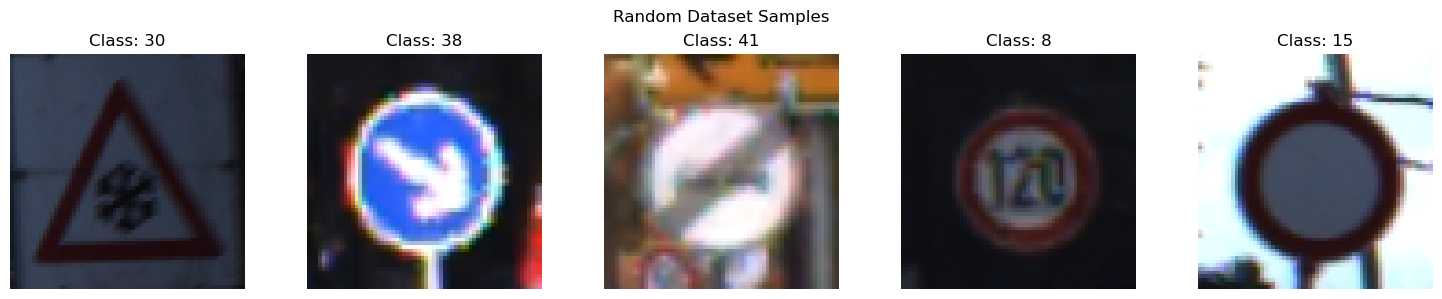

C:\Users\lenar\AppData\Local\Temp\ipykernel_23144\1135343508.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=unique, y=counts, palette="viridis")


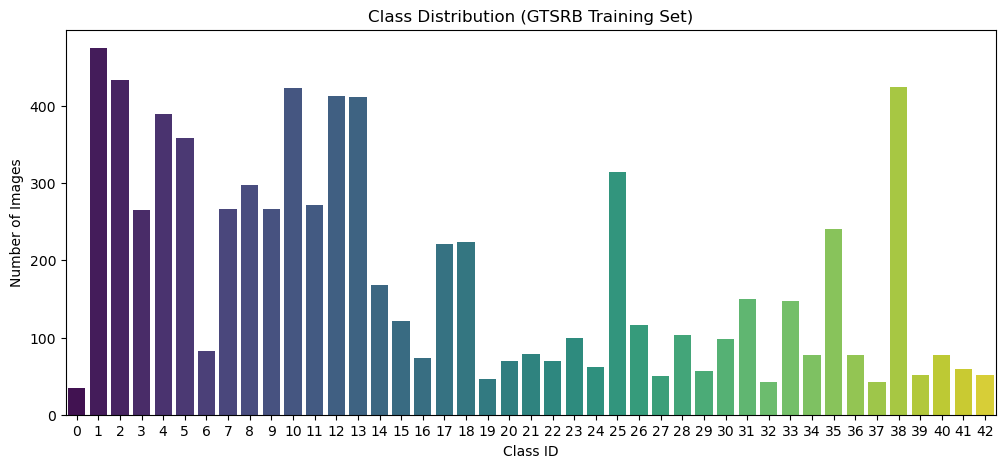

[INFO] analyzing RGB distributions...


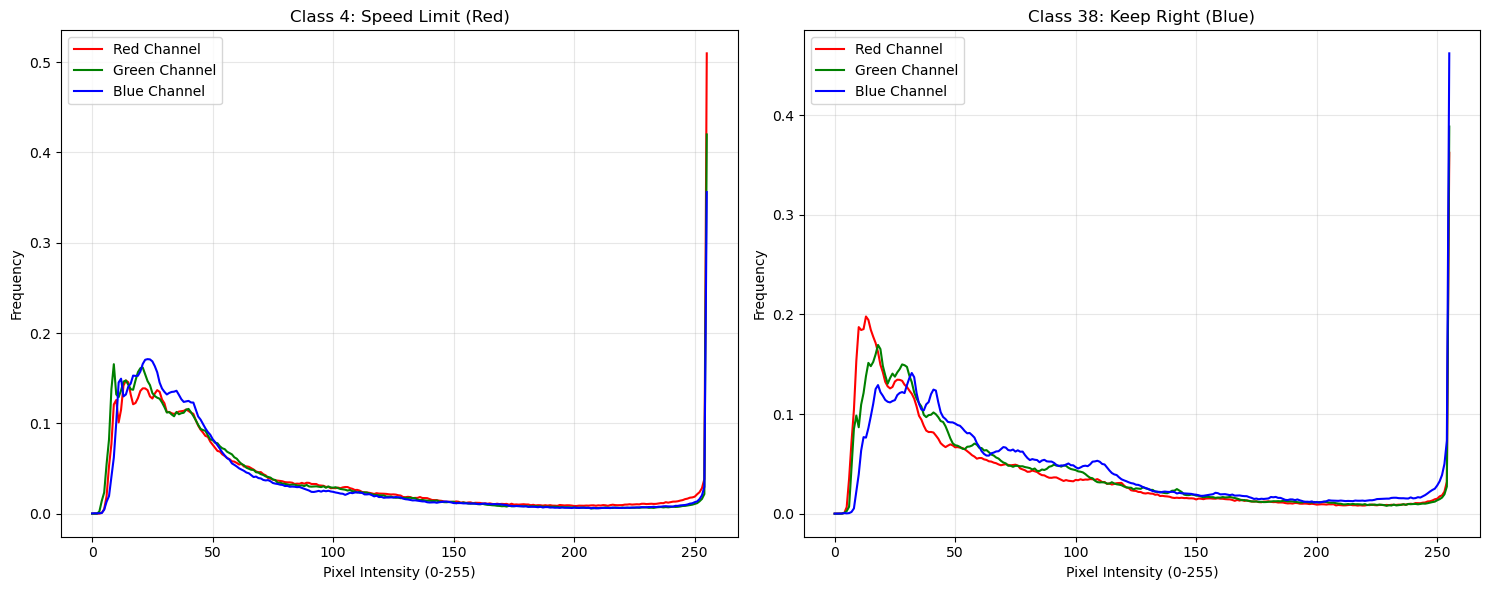

[INFO] Splitting data...

EXPERIMENT 1: COLOR HISTOGRAMS (Simple)
[INFO] Extracting Color Histograms...
[INFO] Extracting Color Histograms...
Optimizing SVM...

--- Training SVM (Color Hist) ---
Accuracy: 0.7660
Training Time: 53.31s
Inference Time: 3.07s

Classification Report:
              precision    recall  f1-score   support

           0      1.000     0.857     0.923         7
           1      0.708     0.842     0.769        95
           2      0.630     0.724     0.674        87
           3      0.706     0.679     0.692        53
           4      0.525     0.679     0.592        78
           5      0.574     0.750     0.651        72
           6      0.867     0.812     0.839        16
           7      0.725     0.698     0.712        53
           8      0.815     0.733     0.772        60
           9      0.700     0.660     0.680        53
          10      0.660     0.776     0.714        85
          11      0.833     0.741     0.784        54
          12     

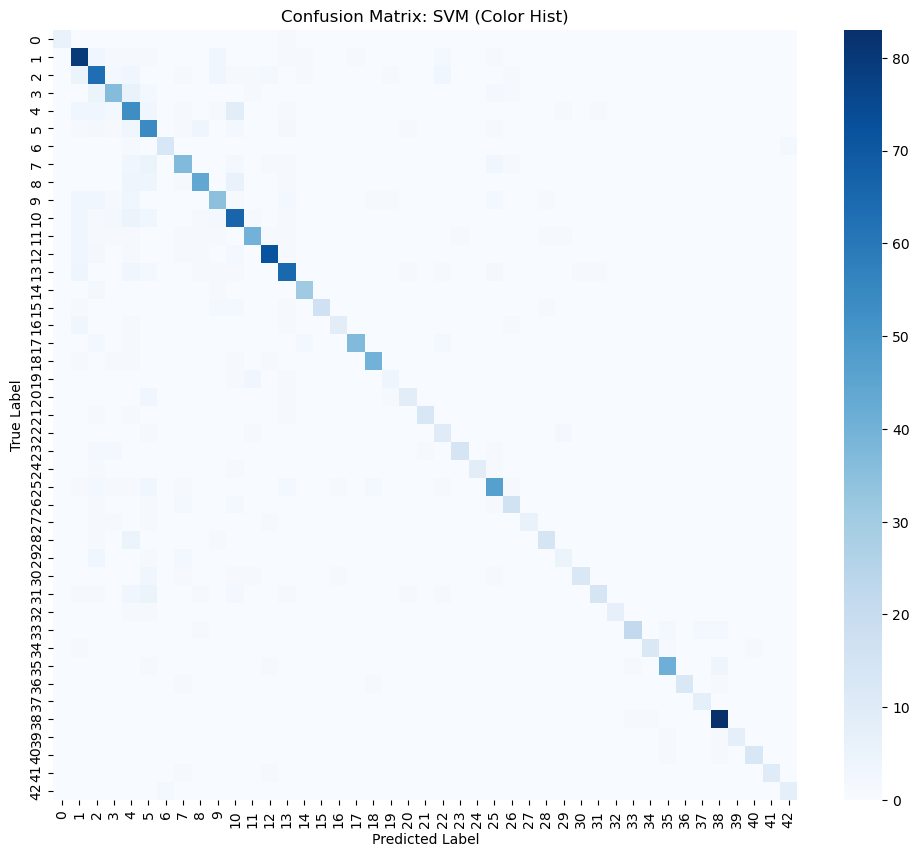


EXPERIMENT 2: SIFT + BoW (Complex)
[INFO] Visualizing SIFT features on a random training sample...


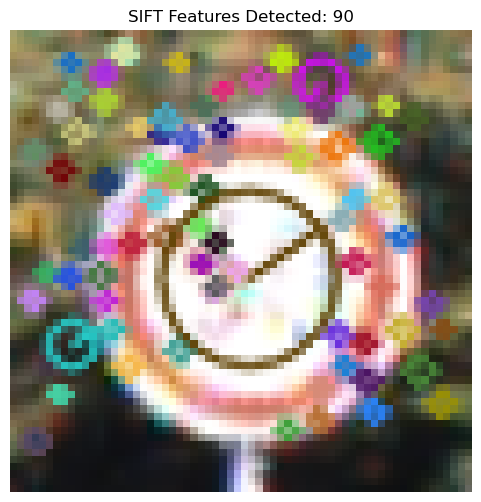

[INFO] BoW: Detecting keypoints for vocabulary generation...
[INFO] BoW: Clustering 25474 descriptors into 100 words...
[INFO] BoW: Vocabulary created.
[INFO] BoW: Encoding images...
[INFO] BoW: Encoding images...

--- Training Random Forest (SIFT BoW) ---
Accuracy: 0.5327
Training Time: 0.25s
Inference Time: 0.03s

Classification Report:
              precision    recall  f1-score   support

           0      1.000     0.143     0.250         7
           1      0.673     0.779     0.722        95
           2      0.744     0.770     0.757        87
           3      0.512     0.415     0.458        53
           4      0.708     0.654     0.680        78
           5      0.580     0.556     0.567        72
           6      0.900     0.562     0.692        16
           7      0.683     0.528     0.596        53
           8      0.300     0.150     0.200        60
           9      0.607     0.642     0.624        53
          10      0.270     0.624     0.377        85
          

c:\Users\lenar\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\lenar\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\lenar\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


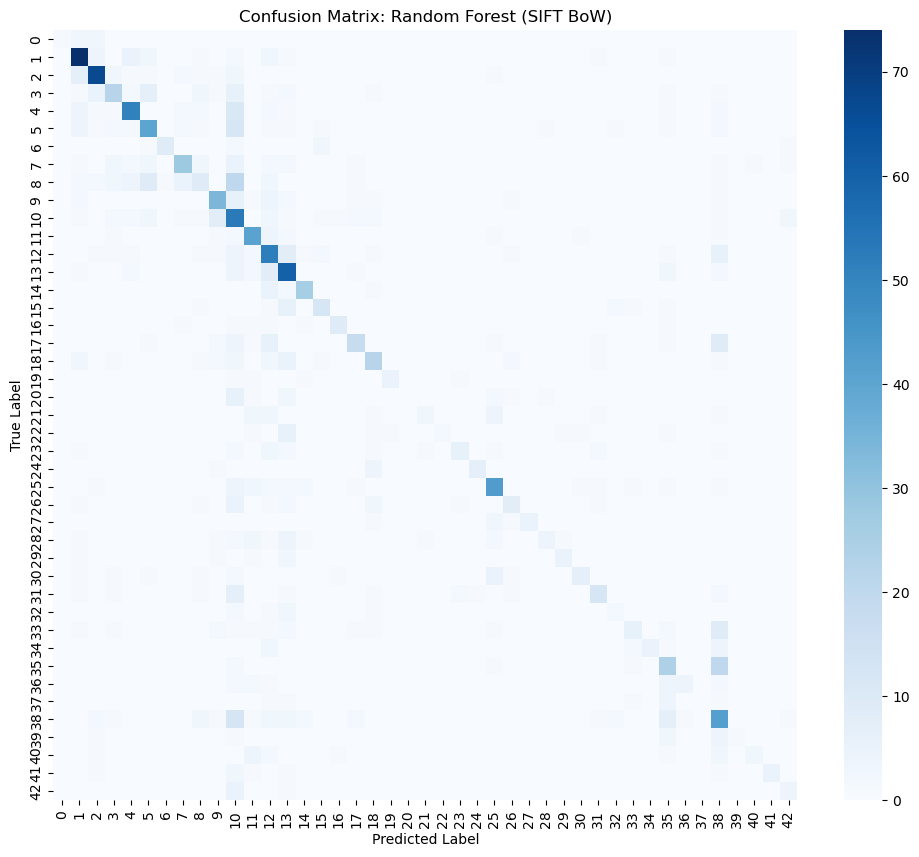


[DONE] Baseline evaluation complete.


In [28]:
# A. Load Data
X, y = load_gtsrb_data(DATASET_PATH, sample_fraction=SAMPLE_FRACTION)

# B. Visualize Data (Requirement: Understanding representation)
plot_samples(X, y)
plot_class_distribution(y)

plot_rgb_histograms_per_class(X, y)
# C. Split Data (Stratified due to class imbalance)
print("[INFO] Splitting data...")
X_train_img, X_test_img, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=SEED
)

# --- EXPERIMENT 1: Color Histogram Features ---
print("\n" + "="*40 + "\nEXPERIMENT 1: COLOR HISTOGRAMS (Simple)\n" + "="*40)

# 1. Extract
X_train_hist = extract_color_histograms(X_train_img)
X_test_hist = extract_color_histograms(X_test_img)

# 2. Train SVM (GridSearch)
print("Optimizing SVM...")
# Using a smaller grid for demonstration; expand for full report
param_grid = {'C': [1, 10], 'gamma': ['scale']} 
svm_grid = GridSearchCV(SVC(kernel='rbf', probability=True), param_grid, cv=3, n_jobs=-1)

y_pred_svm = evaluate_classifier("SVM (Color Hist)", svm_grid, X_train_hist, X_test_hist, y_train, y_test)

# 3. Analyze Errors
plot_confusion_matrix_heatmap(y_test, y_pred_svm, "SVM (Color Hist)")

# --- EXPERIMENT 2: SIFT + Bag of Words ---
print("\n" + "="*40 + "\nEXPERIMENT 2: SIFT + BoW (Complex)\n" + "="*40)

# 1. Inspect Feature Extractor
print("[INFO] Visualizing SIFT features on a random training sample...")
visualize_sift_keypoints(X_train_img[np.random.randint(len(X_train_img))])

# 2. Build Vocabulary (Fit on Train only) & Extract
bow_model = VisualBagOfWords(k=VOCAB_SIZE)
bow_model.fit(X_train_img) 

X_train_bow = bow_model.transform(X_train_img)
X_test_bow = bow_model.transform(X_test_img)

# 3. Train Random Forest
rf_clf = RandomForestClassifier(n_estimators=100, random_state=SEED, n_jobs=-1)

y_pred_rf = evaluate_classifier("Random Forest (SIFT BoW)", rf_clf, X_train_bow, X_test_bow, y_train, y_test)

# 4. Analyze Errors
plot_confusion_matrix_heatmap(y_test, y_pred_rf, "Random Forest (SIFT BoW)")

print("\n[DONE] Baseline evaluation complete.")

In [31]:
test_path = r"C:\Users\lenar\Downloads\GTSRB_Final_Training_Images\GTSRB\Final_Training\Images\00042\00002_00015.ppm"
test_path2 = r"C:\Users\lenar\Downloads\Screenshot 2026-01-11 172800.png"
predict_from_path(test_path2, svm_grid, rf_clf, bow_model)




PREDICTING: C:\Users\lenar\Downloads\Screenshot 2026-01-11 172800.png
[INFO] Extracting Color Histograms...

[Model A] SVM (Color Hist):
   1. Keep right                     | Confidence: 42.12%
   2. Ahead only                     | Confidence: 13.85%
   3. Roundabout mandatory           | Confidence: 7.61%
   4. Yield                          | Confidence: 4.33%
   5. Priority road                  | Confidence: 3.05%
[INFO] BoW: Encoding images...

[Model B] Random Forest (SIFT BoW):
   1. Right-of-way at intersection   | Confidence: 32.00%
   2. Road work                      | Confidence: 17.00%
   3. Keep right                     | Confidence: 4.00%
   4. Children crossing              | Confidence: 4.00%
   5. Bicycles crossing              | Confidence: 4.00%
